# Telco Customer Churn Prediction

## 1. Import Libraries

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [44]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis

In [45]:
df.shape

(7043, 21)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [47]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [48]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [49]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

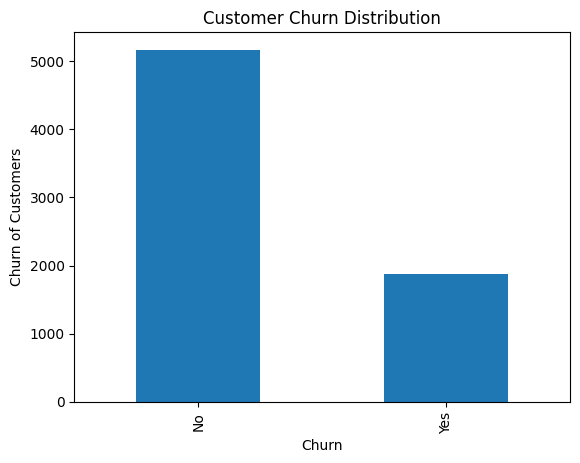

In [50]:
import matplotlib.pyplot as plt
df["Churn"].value_counts().plot(kind="bar")


plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Churn of Customers")
plt.show()

In [51]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [52]:
pd.crosstab(["InternetService"], df["Churn"])

Churn,No,Yes
row_0,,
InternetService,5174,1869


In [53]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


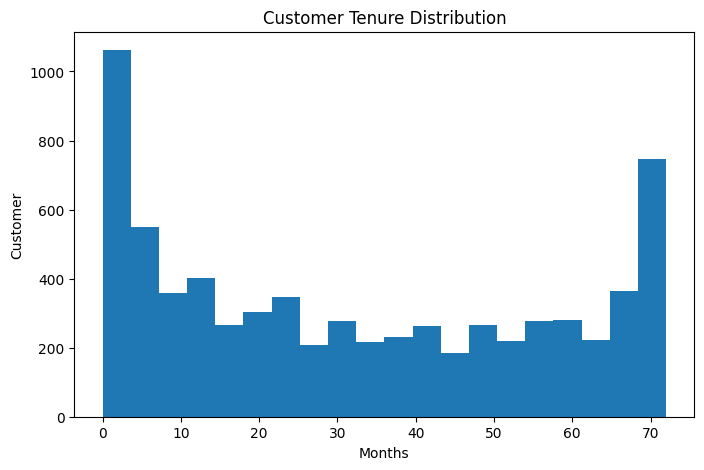

In [54]:
plt.figure(figsize=(8,5))
plt.hist(df["tenure"], bins=20)
plt.title("Customer Tenure Distribution")
plt.xlabel("Months")
plt.ylabel("Customer")
plt.show()

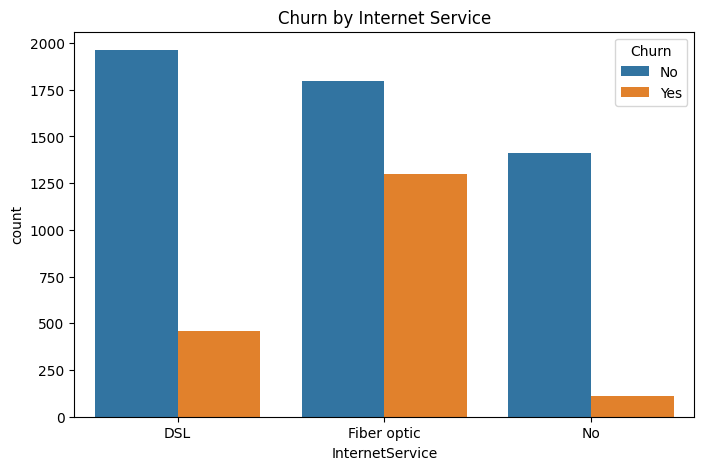

In [55]:

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

## 4. Data Preprocessing

In [56]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [57]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_Yes
0,0,1,29.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,45,42.30,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [58]:
# Create a clean copy
df_clean = df.copy()

# customerID is only an identifier, not a useful predictor
df_clean = df_clean.drop(columns=["customerID"])

# TotalCharges contains blank strings, so convert it to numeric
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Check how many values became missing
df_clean["TotalCharges"].isnull().sum()

np.int64(11)

In [59]:
# Remove the 11 rows with missing TotalCharges
df_clean = df_clean.dropna(subset=["TotalCharges"])

# Convert categorical columns into numeric dummy variables
df_encoded = pd.get_dummies(df_clean, drop_first=True, dtype=int)

df_encoded.shape

(7032, 31)

In [60]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5625, 30)
Testing set: (1407, 30)


## 5. Logistic Regression

In [61]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/Users/faizansyed/ds-customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [62]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7874911158493249

Confusion Matrix:
[[915 118]
 [181 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (5625, 30)
Testing data scaled: (1407, 30)


In [64]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Scaled Logistic Regression trained successfully!")

Scaled Logistic Regression trained successfully!


In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, logistic_pred))
print("Precision:", precision_score(y_test, logistic_pred))
print("Recall:", recall_score(y_test, logistic_pred))
print("F1-score:", f1_score(y_test, logistic_pred))
print("ROC-AUC:", roc_auc_score(y_test, logistic_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))

Accuracy: 0.7874911158493249
Precision: 0.6205787781350482
Recall: 0.516042780748663
F1-score: 0.5635036496350365
ROC-AUC: 0.8319235288940887

Confusion Matrix:
[[915 118]
 [181 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



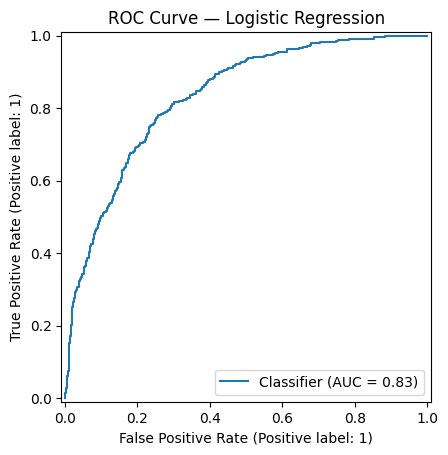

In [66]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    logistic_prob
)

plt.title("ROC Curve — Logistic Regression")
plt.show()

## 6. Decision Tree

In [67]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [68]:
decision_tree_pred = decision_tree_model.predict(X_test)
decision_tree_prob = decision_tree_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, decision_tree_pred))
print("Precision:", precision_score(y_test, decision_tree_pred))
print("Recall:", recall_score(y_test, decision_tree_pred))
print("F1-score:", f1_score(y_test, decision_tree_pred))
print("ROC-AUC:", roc_auc_score(y_test, decision_tree_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, decision_tree_pred))

Accuracy: 0.775408670931059
Precision: 0.5755208333333334
Recall: 0.5909090909090909
F1-score: 0.58311345646438
ROC-AUC: 0.8129662319913445

Confusion Matrix:
[[870 163]
 [153 221]]


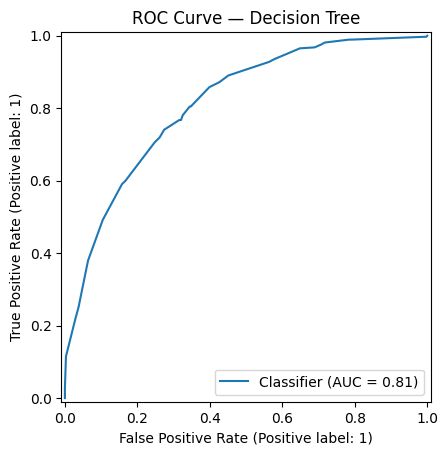

In [69]:
RocCurveDisplay.from_predictions(
    y_test,
    decision_tree_prob
)

plt.title("ROC Curve — Decision Tree")
plt.show()

## 7. Random Forest

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [71]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.7917555081734187
Precision: 0.6472727272727272
Recall: 0.47593582887700536
F1-score: 0.5485362095531587
ROC-AUC: 0.8197374347081084

Confusion Matrix:
[[936  97]
 [196 178]]


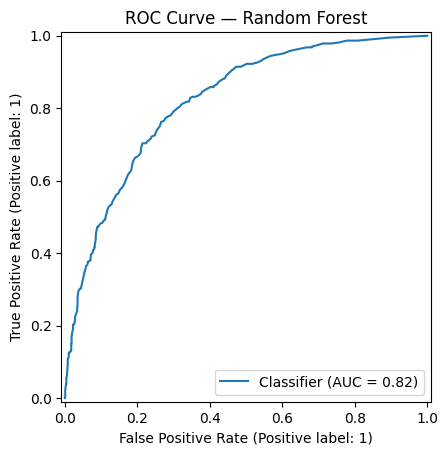

In [72]:
RocCurveDisplay.from_predictions(
    y_test,
    rf_prob
)

plt.title("ROC Curve — Random Forest")
plt.show()

## 8. XGBoost

In [73]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [74]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1-score:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.7903340440653873
Precision: 0.627831715210356
Recall: 0.5187165775401069
F1-score: 0.568081991215227
ROC-AUC: 0.8241609765440984

Confusion Matrix:
[[918 115]
 [180 194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



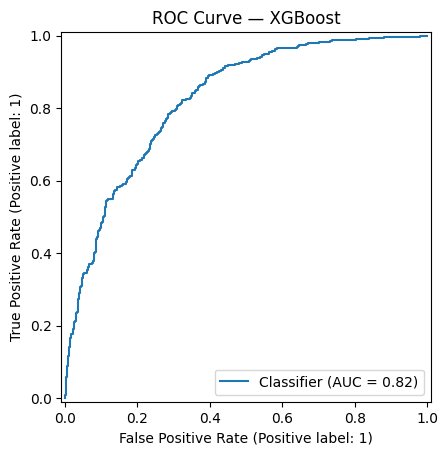

In [75]:
RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob
)

plt.title("ROC Curve — XGBoost")
plt.show()

## 9. Feature Importance

                           Feature  Importance
3                     TotalCharges    0.195146
2                   MonthlyCharges    0.168484
1                           tenure    0.168233
10     InternetService_Fiber optic    0.038646
28  PaymentMethod_Electronic check    0.035524
25               Contract_Two year    0.029168
4                      gender_Male    0.027923
13              OnlineSecurity_Yes    0.027468
26            PaperlessBilling_Yes    0.024851
24               Contract_One year    0.024517


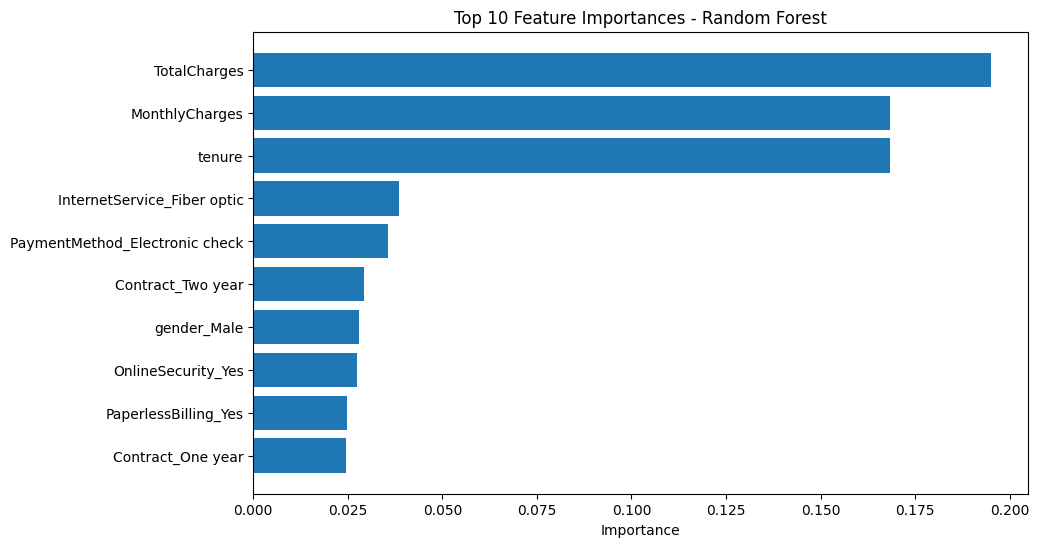

In [76]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calculate feature importance
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top 10 features
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"].head(10)[::-1],
    feature_importance["Importance"].head(10)[::-1]
)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

                           Feature  Importance
10     InternetService_Fiber optic    0.449174
25               Contract_Two year    0.168174
24               Contract_One year    0.084847
11              InternetService_No    0.077897
23             StreamingMovies_Yes    0.026498
1                           tenure    0.025204
28  PaymentMethod_Electronic check    0.013334
19                 TechSupport_Yes    0.012886
7                 PhoneService_Yes    0.012556
13              OnlineSecurity_Yes    0.012476


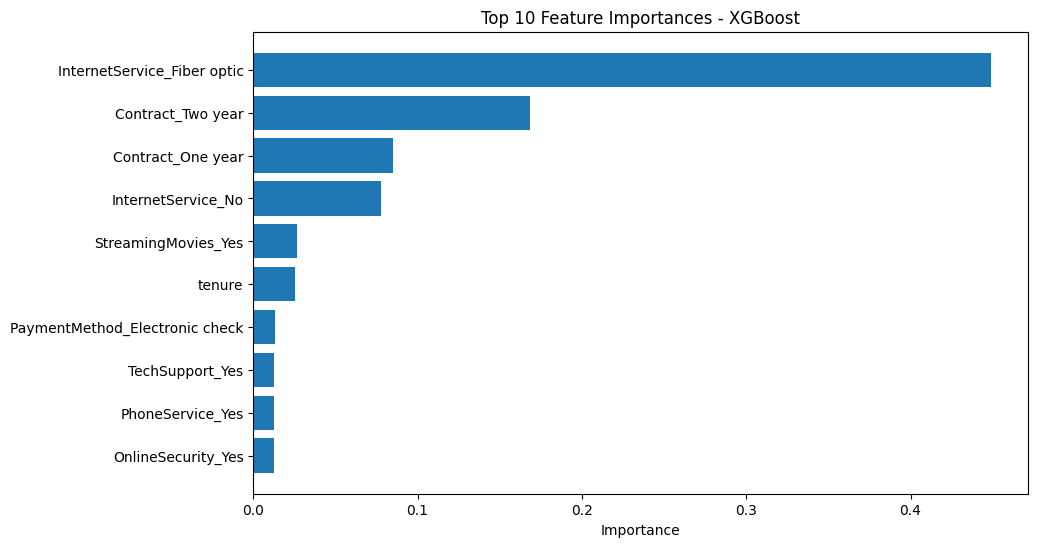

In [77]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    xgb_importance["Feature"].head(10)[::-1],
    xgb_importance["Importance"].head(10)[::-1]
)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - XGBoost")
plt.show()

## 10. Model Comparison

In [78]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, decision_tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, decision_tree_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, decision_tree_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, decision_tree_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, decision_tree_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.787,0.621,0.516,0.564,0.832
1,Decision Tree,0.775,0.576,0.591,0.583,0.813
2,Random Forest,0.792,0.647,0.476,0.549,0.820
3,XGBoost,0.790,0.628,0.519,0.568,0.824


## 11. Conclusion

In this project, multiple machine learning models were developed to predict customer churn using the Telco Customer Churn dataset. Logistic Regression, Decision Tree, Random Forest, and XGBoost were trained and evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Among the models, XGBoost achieved the highest ROC-AUC (0.824), while Random Forest achieved the highest accuracy (0.792). Feature importance analysis showed that Internet Service type, contract type, tenure, and monthly charges were among the most important factors influencing customer churn. These results demonstrate that machine learning can effectively identify customers at risk of churning and can support businesses in developing targeted customer retention strategies.

